In [12]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
from dash import html, dcc
from dash.dependencies import Input, Output


df = pd.read_csv("data/properati_caba.csv")

def quality_report(df):
    report = pd.DataFrame({
        "nulos": df.isnull().sum(),
        "%_nulos": (df.isnull().sum() / len(df) * 100).round(2),
        "tipos": df.dtypes,
        "unicos": df.nunique()
    })
    return report

mask_surface_error = df["surface_covered"] > df["surface_total"]

display(Markdown(f"### Registros con error de superficie (Cubierta > Total): {mask_surface_error.sum()}"))
display(quality_report(df))

### Registros con error de superficie (Cubierta > Total): 1583

,nulos,%_nulos,tipos,unicos
start_date,0,0.00,object,346
end_date,0,0.00,object,448
created_on,0,0.00,object,346
lat,32155,12.88,float64,72664
lon,32033,12.83,float64,71703
rooms,78289,31.35,float64,32
bedrooms,127386,51.01,float64,65
bathrooms,37245,14.91,float64,18
surface_total,77958,31.22,float64,1737
surface_covered,84393,33.79,float64,1523


#### Data Wrangling: saneamiento de información inmobiliaria
Luego observar y marcar los errores en el conjunto, se procede a eliminar el ruido aleatorio y generar información valiosa: eliminación de valores nulos en variables que no se pueden recuperar o absurdos que vuelven descartable sus registros e imputación de valores faltantes mediante las categorías más propensas o su cercanía a otros casos, además, a partir de columnas irrelevanes generar nuevas que aporten un mayor valor explicativo.

In [13]:
df["lat"], df["lon"] = df["lon"], df["lat"]

df.dropna(subset=["lat","lon","surface_covered","price","currency"], inplace=True)
df = df[df["surface_covered"] <= df["surface_total"]]

cols_mode = ["rooms","bedrooms","bathrooms"]

for col in cols_mode:
    if col in df.columns:
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)

imputer = KNNImputer(n_neighbors=5)
cols_knn = ["lat","lon","rooms","bathrooms","bedrooms","surface_covered","price","surface_total"]

imputed_array = imputer.fit_transform(df[cols_knn])
df["surface_total"] = imputed_array[:, -1]

def get_dolar():
    try:
        res = requests.get("https://dolarapi.com/v1/dolares/blue", timeout=3)
        return float(res.json()["venta"])
    except:
        return 1360.0

dolar_value = get_dolar()
currency_ARS = df.loc[df["currency"] == "ARS", "price"]
df.loc[df["currency"] == "ARS", "price"] = currency_ARS / dolar_value

df["end_date"] = df["end_date"].astype(str).mask(df["end_date"].astype(str).str.startswith("9999", na=False), np.nan)

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

today = pd.to_datetime("today")
publicate_days = (df["end_date"].fillna(today) - df["start_date"]).dt.days
status = np.where(df["end_date"].isna(), "Activo", "Finalizado")

df.insert(2, "publicate_days", publicate_days)
df.insert(3, "status", status)

df = df.drop(["start_date","end_date","created_on","currency"], axis=1)

df.loc[df["operation_type"] == "Venta", "price_period"] = "Pago único"

df_sales = df[df["operation_type"] == "Venta"].copy()
df_rents = df[df["operation_type"] == "Alquiler"].copy()
df_temp_rents = df[df["operation_type"] == "Alquiler temporal"].copy()

rent_mode = df_rents["price_period"].mode()[0]
df_rents.loc[:, "price_period"] = df_rents["price_period"].fillna(rent_mode)
temp_rent_mode = df_temp_rents["price_period"].mode()[0]
df_temp_rents.loc[:, "price_period"] = df_temp_rents["price_period"].fillna(temp_rent_mode)

df.loc[df["operation_type"] == "Alquiler", "price_period"] = df_rents["price_period"]
df.loc[df["operation_type"] == "Alquiler temporal", "price_period"] = df_temp_rents["price_period"]

display(Markdown("### Dataset estructurado"))
display(df)

### Dataset estructurado

,publicate_days,status,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price_period,property_type,operation_type,price
1,3,Finalizado,-34.606620,-58.430493,3.0,2.0,2.0,77.0,67.0,Pago único,Departamento,Venta,235500.0
2,2210,Activo,-34.574123,-58.491760,2.0,1.0,1.0,60.0,55.0,Pago único,Departamento,Venta,175000.0
3,2529,Activo,-34.631770,-58.420737,2.0,1.0,1.0,74.0,47.0,Pago único,PH,Venta,140000.0
4,26,Finalizado,-34.607225,-58.429983,3.0,2.0,1.0,66.0,64.0,Pago único,Departamento,Venta,173000.0
5,16,Finalizado,-34.608640,-58.420780,3.0,2.0,1.0,55.0,55.0,Pago único,PH,Venta,155000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249715,15,Finalizado,-34.607180,-58.414390,2.0,7.0,5.0,640.0,420.0,Pago único,Casa,Venta,680000.0
249716,15,Finalizado,-34.616006,-58.412690,2.0,7.0,5.0,1309.0,1000.0,Pago único,Casa,Venta,1100000.0
249724,15,Finalizado,-34.601908,-58.441457,2.0,1.0,5.0,1100.0,1100.0,Mensual,Local comercial,Alquiler,13000.0
249729,35,Finalizado,-34.589703,-58.389826,4.0,3.0,5.0,153.0,153.0,Pago único,Departamento,Venta,550000.0


#### Clustering: segmentación analítica del mercado
El siguiente objetivo técnico y de negocio será el conglomerado de las ofertas según su comportamiento y características intrínsecas, generando umbrales que guíen tanto a modelos computacionales como a usuarios finales en la detección de oportunidades reales y anomalías de precios.

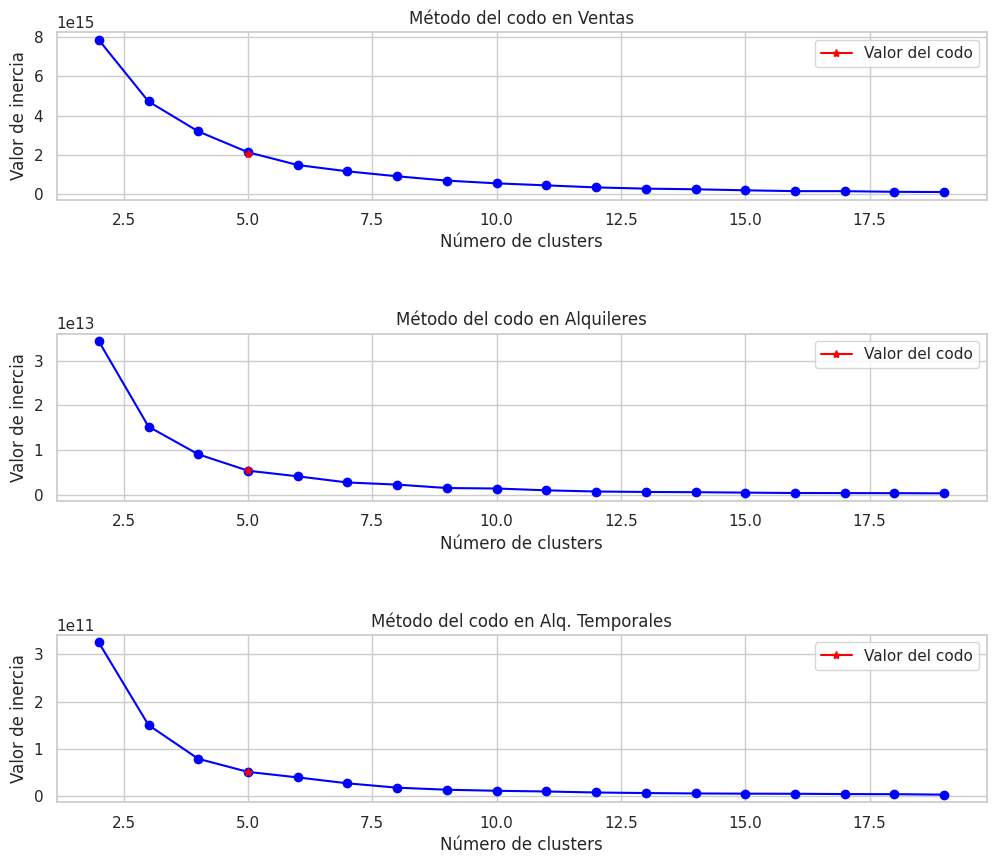

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

def add_fig(df, ax, i):
    clusters = []
    inertias = []
    plot_titles = ["Ventas", "Alquileres", "Alq. Temporales"]

    for c in range(2,20):
        kmeans = KMeans(n_clusters=c).fit(df["price"].values.reshape((-1,1)))
        clusters.append(c)
        inertias.append(kmeans.inertia_)

    cluster_elbow = 5
    kmeans = KMeans(n_clusters=cluster_elbow).fit(df["price"].values.reshape((-1,1)))
    inertia_elbow = kmeans.inertia_

    ax[i].plot(clusters, inertias, marker="o", c="blue")
    ax[i].plot(cluster_elbow, inertia_elbow, marker="*", c="red", label="Valor del codo")
    ax[i].set_xlabel("Número de clusters")
    ax[i].set_ylabel("Valor de inercia")
    ax[i].set_title(f"Método del codo en {plot_titles[i]}")
    ax[i].grid("on")
    ax[i].legend()

add_fig(df_sales, ax, 0)
add_fig(df_rents, ax, 1)
add_fig(df_temp_rents, ax, 2)

plt.subplots_adjust(hspace=0.8)
plt.show()

#### Boosting: herramienta computacional de tasación precisa
A diferencia de los metaestimadores horizontales, este caso exige una capacidad de procesamiento superior para ejecutar un aprendizaje serial y obsesivo. Cada iteración es un filtro de calidad que limpia el ruido de la volatilidad, generando umbrales que guíen la inversión con una agudeza que la intuición humana no puede procesar a esa velocidad, combinada con la especialización de estructuras independientes según el tipo de operación llevado a cabo. Esta arquitectura de modelos especializados se almacena con un propósito crítico: una posterior puesta en producción donde actúan como un mecanismo de redundancia, garantizando la continuidad de las tasaciones automatizadas e imputando de forma inteligente los valores ante escenarios de pérdida o ausencia de información en los registros de origen.

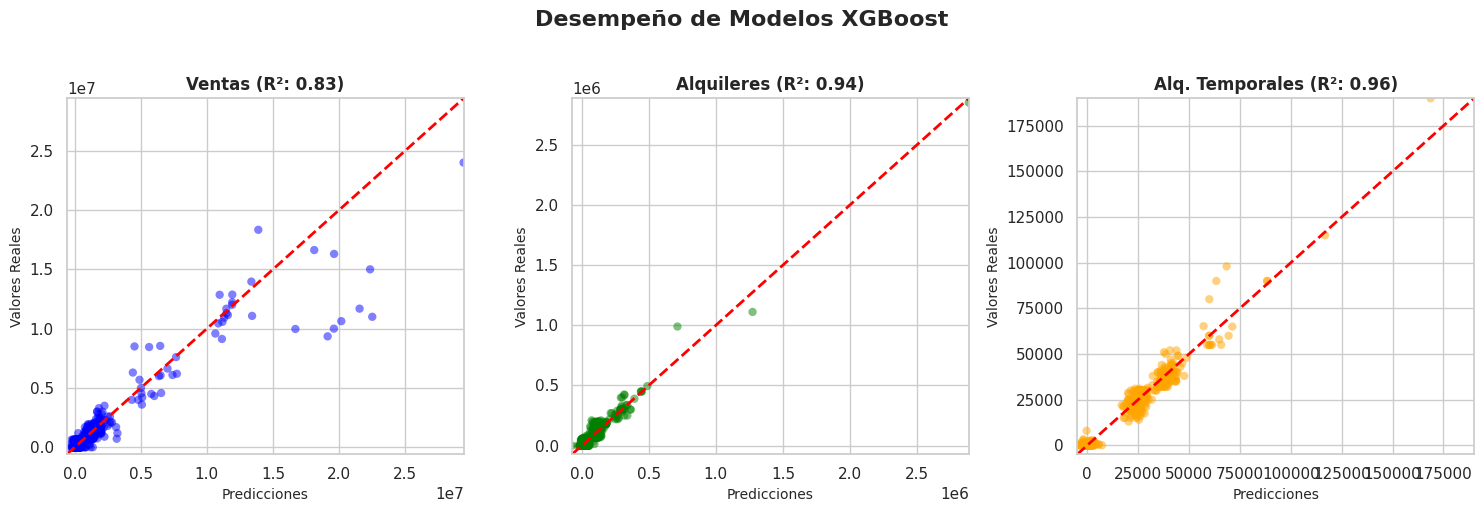

In [14]:
n_clusters = 5
def clustering(df):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(df[["price"]])
    clusters = kmeans.labels_
    return clusters

df_sales["clusters"] = clustering(df_sales)
df_rents["clusters"] = clustering(df_rents)
df_temp_rents["clusters"] = clustering(df_temp_rents)

categories = ["status", "property_type", "operation_type", "price_period"]
numerics = ["lat", "lon", "publicate_days", "surface_total", "surface_covered"]

def create_model_safe(df):
    X = df.drop(columns=["price"])
    y = df["price"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    current_categories = [col for col in categories if col in X.columns]
    current_numerics = [col for col in numerics if col in X.columns]

    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    mm_scaler = MinMaxScaler()

    X_train_cat = encoder.fit_transform(X_train[current_categories])
    X_train_num = mm_scaler.fit_transform(X_train[current_numerics])

    X_test_cat = encoder.transform(X_test[current_categories])
    X_test_num = mm_scaler.transform(X_test[current_numerics])

    X_train_proc = X_train.copy()
    X_train_proc[current_categories] = X_train_cat.astype(int)
    X_train_proc[current_numerics] = X_train_num

    X_test_proc = X_test.copy()
    X_test_proc[current_categories] = X_test_cat.astype(int)
    X_test_proc[current_numerics] = X_test_num

    if "price_period" in X_train_proc.columns:
        X_train_proc = X_train_proc.drop(columns=["price_period"])
        X_test_proc = X_test_proc.drop(columns=["price_period"])

    turned_parameters = {
        "n_estimators": [100, 200, 300, 400, 500],
        "subsample": [0.7, 0.75, 0.8, 0.85, 0.9],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.2, 0.3, 0.4, 0.5, 0.55],
        "min_child_weight": [2, 3, 4, 5, 6],
        "gamma": [0, 1, 2, 3, 4]
    }

    xgbr_search = XGBRegressor(random_state=42)

    random_search = RandomizedSearchCV(xgbr_search, turned_parameters, cv=5, n_iter=10, random_state=42)
    random_search.fit(X_train_proc, y_train)

    xgbr = XGBRegressor(**random_search.best_params_, random_state=42)
    xgbr.fit(X_train_proc, y_train)

    predictions = xgbr.predict(X_test_proc)

    return xgbr, y_test, predictions


xgbr_sales, real_sales, sales_predictions = create_model_safe(df_sales)
xgbr_rents, real_rents, rents_predictions = create_model_safe(df_rents)
xgbr_temp_rents, real_temp_rents, temp_rents_predictions = create_model_safe(df_temp_rents)

r2_sales = r2_score(real_sales, sales_predictions)
r2_rents = r2_score(real_rents, rents_predictions)
r2_temp_rents = r2_score(real_temp_rents, temp_rents_predictions)

models_data = [
    {"name": "Ventas", "real": real_sales, "pred": sales_predictions, "color": "blue"},
    {"name": "Alquileres", "real": real_rents, "pred": rents_predictions, "color": "green"},
    {"name": "Alq. Temporales", "real": real_temp_rents, "pred": temp_rents_predictions, "color": "orange"}
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=False)

subplot_titles = [
    f"Ventas (R²: {r2_sales:.2f})",
    f"Alquileres (R²: {r2_rents:.2f})",
    f"Alq. Temporales (R²: {r2_temp_rents:.2f})"
]

for i, (data, ax) in enumerate(zip(models_data, axes)):

    sns.scatterplot(
        x=data["pred"],
        y=data["real"],
        color=data["color"],
        alpha=0.5,
        edgecolor="none",
        ax=ax
    )

    min_val = min(min(data["real"]), min(data["pred"]))
    max_val = max(max(data["real"]), max(data["pred"]))

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(subplot_titles[i], fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicciones", fontsize=10)
    ax.set_ylabel("Valores Reales", fontsize=10)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

fig.suptitle("Desempeño de Modelos XGBoost", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

#### Herramienta interactiva que combina cartografía geoespacial modificable junto con análisis de rangos monetarios

In [ ]:
cols =  ["operation_type", "price_period", "status", "property_type", "price", "lat", "lon"]
df = df.loc[:, cols]

app = dash.Dash(__name__)

app.layout = html.Div(id="body",className="e7_body",children=[
        html.H1("Análisis del mercado inmobiliario de CABA",id="title",className="e7_title",style={"margin-bottom":"50px"}),
        html.Div(id="div_dropdown",className="e7_div_dropdown",children=[
            dcc.Dropdown(id="dropdown_1",className="e7_dropdown",
                        options=df["operation_type"].unique().tolist(),
                        value=df["operation_type"].unique()[0],
                        multi=False,
                        clearable=False),
            dcc.Dropdown(id="dropdown_2",className="e7_dropdown",
                        options=df["price_period"].unique().tolist(),
                        value=df["price_period"].unique()[0],
                        multi=False,
                        clearable=False),
            dcc.Dropdown(id="dropdown_3",className="e7_dropdown",
                        options=df["status"].unique().tolist(),
                        value=df["status"].unique()[0],
                        multi=False,
                        clearable=False),
            dcc.Dropdown(id="dropdown_4",className="e7_dropdown",
                        options=df["property_type"].unique().tolist(),
                        value=df["property_type"].unique()[0],
                        multi=False,
                        clearable=False)
        ]),
        dcc.Graph(id="graph_1",className="e7_graph",figure={}),
        dcc.Graph(id="graph_2",className="e7_graph",figure={})
])

@app.callback(
    [Output(component_id="graph_1",component_property="figure"),
    Output(component_id="graph_2",component_property="figure")],
    [Input(component_id="dropdown_1",component_property="value"),
    Input(component_id="dropdown_2",component_property="value"),
    Input(component_id="dropdown_3",component_property="value"),
    Input(component_id="dropdown_4",component_property="value")]
)

def update_dashboard(slct_operation, slct_price_period, slct_status, slct_property):
    df_filtered = df.loc[(df["operation_type"] == slct_operation) & (df["price_period"] == slct_price_period) & (df["status"] == slct_status) & (df["property_type"] == slct_property), :].copy()
    df_filtered.dropna(inplace=True)

    if df_filtered.empty or len(df_filtered) < 5:
        fig_empty = go.Figure().update_layout(title="Sin datos suficientes para esta selección",template="plotly_dark")
        return fig_empty, fig_empty

    df_filtered["lat"] = pd.to_numeric(df_filtered["lat"], errors="coerce")
    df_filtered["lon"] = pd.to_numeric(df_filtered["lon"], errors="coerce")

    caba_map = go.Figure(go.Scattermapbox(
        lat=df_filtered["lat"],
        lon=df_filtered["lon"],
        mode="markers",
        text=df_filtered["price"],
        hovertemplate=(
            "Precio: USD %{text:,.0f}<br>" +
            "Lat: %{lat:.4f}<br>" +
            "Lon: %{lon:.4f}<extra></extra>"
        ),
        marker=go.scattermapbox.Marker(
            size=8,
            color=df_filtered["price"],
            cmin=df_filtered["price"].min(),
            cmax=df_filtered["price"].max(),
            showscale=True,
            colorbar=dict(title="Precios")
        )
    ))

    caba_map.update_layout(
        mapbox_style="open-street-map",
        mapbox_zoom=11.5,
        mapbox_center={"lat": -34.6037, "lon": -58.4417},
        margin={"r":0,"t":0,"l":0,"b":0}
    )

    prices_filter = {
        "Venta": (10000, 10000000),
        "Alquiler": (150, 15000),
        "Alquiler temporal": (200, 20000)
    }

    min_p, max_p = prices_filter.get(slct_operation, (10000, 10000000))
    df_filtered = df_filtered[df_filtered["price"].between(min_p, max_p)].copy()

    price_data = np.log1p(df_filtered["price"]) if slct_operation == "Venta" else df_filtered["price"]
    scaled_price = RobustScaler().fit_transform(price_data.values.reshape(-1, 1))

    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    df_filtered["clusters"] = kmeans.fit_predict(scaled_price)

    cluster_stats = df_filtered.groupby("clusters")["price"].agg(["min", "max", "count"]).sort_values("min")

    label_map = {
        idx: f"Rango {i+1}: (${int(row["min"]):,} - ${int(row["max"]):,})"
        for i, (idx, row) in enumerate(cluster_stats.iterrows())
    }

    df_filtered["cluster_label"] = df_filtered["clusters"].map(label_map)

    clusters_analysis = make_subplots(
        rows=2, cols=1,
        subplot_titles=["Distribución Geográfica por Rango", "Cantidad de Propiedades"],
        vertical_spacing=0.2
    )

    for label in sorted(df_filtered["cluster_label"].unique()):
        df_c = df_filtered[df_filtered["cluster_label"] == label]
        clusters_analysis.add_trace(
            go.Scatter(
                x=df_c["lon"],
                y=df_c["lat"],
                mode="markers",
                name=label,
                marker=dict(size=6),
                hovertemplate=f"<b>{label}</b><br>Lat: %{{y}}<br>Lon: %{{x}}<extra></extra>"
            ), row=1, col=1
        )

    clusters_analysis.update_xaxes(showgrid=False, zeroline=False, row=1, col=1)
    clusters_analysis.update_yaxes(showgrid=False, zeroline=False, scaleanchor="x", scaleratio=1, row=1, col=1)

    counts = df_filtered["cluster_label"].value_counts().reset_index()

    clusters_analysis.add_trace(go.Bar(x=counts["cluster_label"], y=counts["count"], name="Cantidad"), row=2, col=1)
    clusters_analysis.update_layout(height=850, template="plotly_dark", margin=dict(r=25, t=75, l=25, b=25))

    return caba_map, clusters_analysis

if __name__ == "__main__":
    app.run(debug=False)